# Przewidywanie wyników edukacyjnych studentów na podstawie czynników behawioralnych i poznawczych

Celem projektu jest stworzenie modeli uczenia maszynowego, które przewidują wartość Performance Index na podstawie takich zmiennych jak liczba godzin nauki, wcześniejsze wyniki, sen, aktywność pozalekcyjna oraz liczba przerobionych arkuszy próbnych.

Jest to zadanie regresji, ponieważ przewidujemy wartość liczbową.

## Źródło danych

W projekcie wykorzystano zbiór „Student Performance” pobrany z platformy Kaggle. Zbiór zawiera 10 000 obserwacji i 6 zmiennych opisujących czynniki związane z nauką oraz wynik Performance Index.

Plik `Student_Performance.csv` został umieszczony w repozytorium razem z notebookiem.

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [56]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [57]:
df.shape

(10000, 6)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [59]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [60]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [61]:
print("Liczba duplikatów:", df.duplicated().sum())

Liczba duplikatów: 127


In [62]:
df = df.drop_duplicates()

print("Liczba wierszy po usunięciu duplikatów:", df.shape[0])
print("Liczba pozostałych duplikatów:", df.duplicated().sum())

Liczba wierszy po usunięciu duplikatów: 9873
Liczba pozostałych duplikatów: 0


### Usunięcie duplikatów

W zbiorze wykryto 127 całkowicie identycznych wierszy. Zostały one usunięte, aby uniknąć wielokrotnego uwzględniania tych samych obserwacji oraz ryzyka, że identyczne rekordy znajdą się jednocześnie w zbiorze treningowym i testowym. Po usunięciu duplikatów zbiór zawiera 9873 obserwacje.

In [63]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


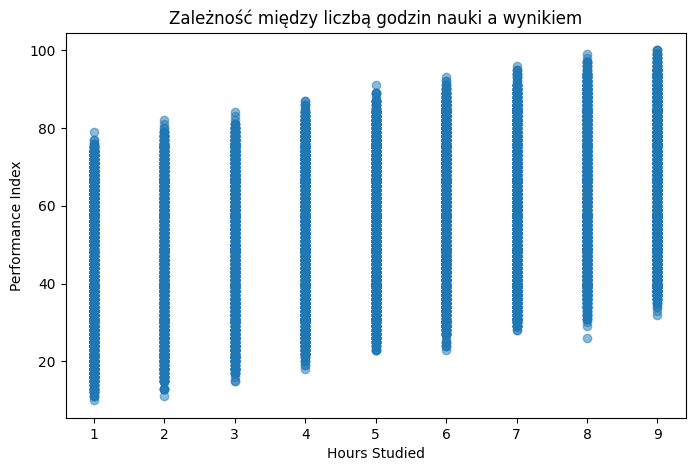

In [64]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Hours Studied"], df["Performance Index"], alpha=0.5)

plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.title("Zależność między liczbą godzin nauki a wynikiem")

plt.show()

### Interpretacja

Wykres pokazuje dodatnią zależność między liczbą godzin nauki a wartością Performance Index. Wraz ze wzrostem liczby godzin nauki wyniki zazwyczaj rosną. Jednocześnie dla tej samej liczby godzin występuje zróżnicowanie wyników, co sugeruje, że na osiągnięcia edukacyjne wpływają również inne czynniki.

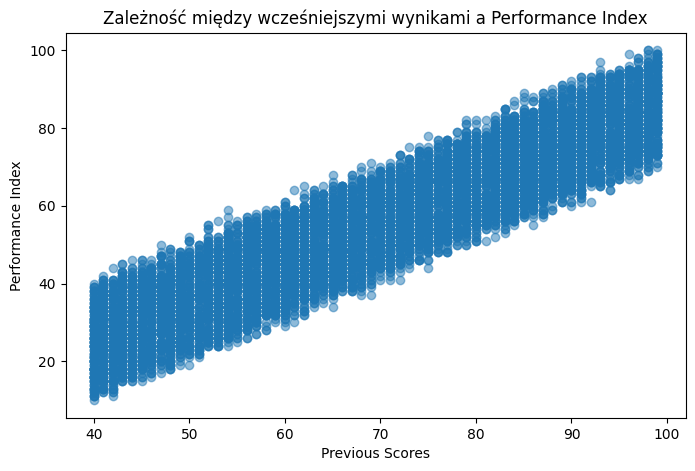

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Previous Scores"], df["Performance Index"], alpha=0.5)

plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")
plt.title("Zależność między wcześniejszymi wynikami a Performance Index")

plt.show()

### Interpretacja

Wykres pokazuje wyraźną dodatnią zależność między wcześniejszymi wynikami a wartością Performance Index. Oznacza to, że osoby, które wcześniej osiągały lepsze rezultaty, zazwyczaj uzyskują również wyższy wynik końcowy.

Punkty układają się w rosnący wzorzec, co sugeruje, że zmienna Previous Scores może być jednym z najważniejszych predyktorów w modelu. Jednocześnie wyniki nie układają się idealnie w jedną linię, dlatego wcześniejsze osiągnięcia nie są jedynym czynnikiem wpływającym na Performance Index.


Macierz korelacji (tabela):


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


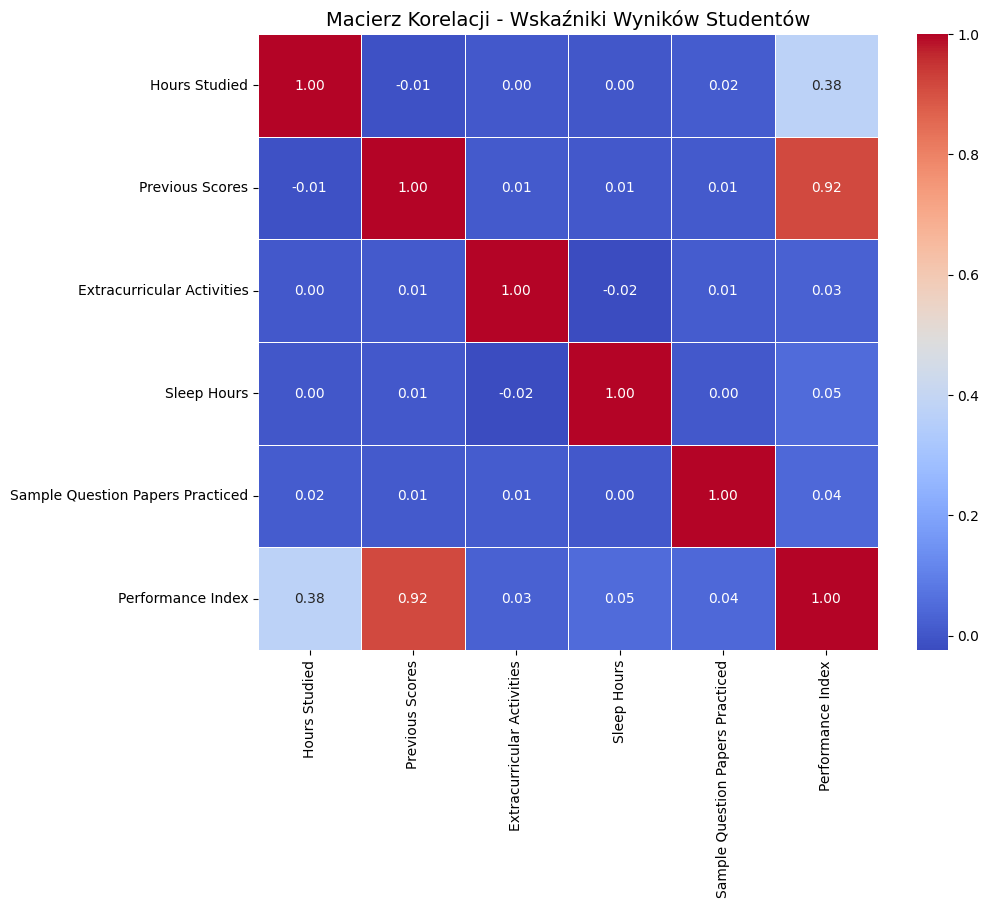

In [66]:
# 3. Obliczenie macierzy korelacji
correlation_matrix = df.corr()

# 4. Wyświetlenie macierzy w formie tekstowej
print("Macierz korelacji (tabela):")
display(correlation_matrix)

# 5. Wizualizacja za pomocą Heatmapy (Seaborn)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Macierz Korelacji - Wskaźniki Wyników Studentów", fontsize=14)
plt.show()

### Interpretacja macierzy korelacji

Macierz korelacji pokazuje siłę zależności liniowych między zmiennymi. Najsilniejszą dodatnią korelację z Performance Index ma zmienna Previous Scores, dla której współczynnik korelacji wynosi około 0,92. Oznacza to, że osoby osiągające wysokie wcześniejsze wyniki zazwyczaj uzyskują również wysoki Performance Index.

Drugą najsilniejszą zależność obserwujemy dla zmiennej Hours Studied. Współczynnik około 0,37 wskazuje na umiarkowaną dodatnią korelację, czyli wraz ze wzrostem liczby godzin nauki wynik zazwyczaj rośnie.

Pozostałe zmienne mają słabe korelacje liniowe z Performance Index. Nie oznacza to jednak, że są całkowicie nieistotne, ponieważ modele nieliniowe mogą wykrywać bardziej złożone zależności między cechami.


In [67]:
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

print(X.head())
print()
print(y.head())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  

0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7898, 5)
X_test: (1975, 5)
y_train: (7898,)
y_test: (1975,)


In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("RMSE:", rmse_linear)
print("R²:", r2_linear)

RMSE: 2.0750664901488047
R²: 0.9884301209927054


### Interpretacja regresji liniowej

Model regresji liniowej osiągnął RMSE na poziomie około 2,08. Oznacza to, że typowa wielkość błędu predykcji wynosi około 2,08 punktu Performance Index. Wartość R² wyniosła około 0,988, co wskazuje, że model wyjaśnia około 98,8% zróżnicowania wartości Performance Index.


In [71]:
from sklearn.tree import DecisionTreeRegressor

# Tworzenie i uczenie modelu drzewa decyzyjnego
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Przewidywanie wyników dla zbioru testowego
tree_predictions = tree_reg.predict(X_test)

# Obliczanie RMSE dla zbioru testowego
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)

print(f"Decision Tree Test RMSE: {tree_rmse:.2f}")

Decision Tree Test RMSE: 3.03


### Interpretacja wyniku drzewa decyzyjnego

Model Decision Tree Regressor osiągnął RMSE na poziomie około 3,03. Oznacza to, że typowa wielkość błędu predykcji wynosi około 3,03 punktu Performance Index.

W porównaniu z regresją liniową, która uzyskała RMSE około 2,08, drzewo decyzyjne poradziło sobie gorzej. Na tym etapie lepszym modelem jest więc regresja liniowa.


In [72]:
from sklearn.model_selection import cross_val_score

# 10-krotna walidacja krzyżowa dla drzewa decyzyjnego
tree_scores = cross_val_score(
    tree_reg,
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=10
)

tree_rmse_scores = np.sqrt(-tree_scores)

print("Wyniki RMSE:", tree_rmse_scores)
print("Średnie RMSE:", tree_rmse_scores.mean())
print("Odchylenie standardowe:", tree_rmse_scores.std())

Wyniki RMSE: [3.07053164 3.07037704 3.14326239 3.05114629 3.12513853 3.12743295
 2.89941553 3.09920365 2.98851838 2.99196219]
Średnie RMSE: 3.0566988597506475
Odchylenie standardowe: 0.07278319378413955


### Interpretacja walidacji krzyżowej

W 10-krotnej walidacji krzyżowej model Decision Tree Regressor uzyskał średnie RMSE na poziomie około 3,06. Oznacza to, że typowa wielkość błędu predykcji w kolejnych podziałach danych wynosiła około 3,06 punktu Performance Index.

Wynik walidacji krzyżowej jest zbliżony do RMSE uzyskanego na zbiorze testowym, które wyniosło około 3,03. Sugeruje to, że ocena modelu jest stabilna i nie zależy wyłącznie od jednego podziału danych.


In [73]:
from sklearn.ensemble import RandomForestRegressor

# Tworzenie i uczenie modelu Random Forest
forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_reg.fit(X_train, y_train)

# Przewidywanie wyników dla zbioru testowego
forest_predictions = forest_reg.predict(X_test)

# Obliczanie RMSE
forest_mse = mean_squared_error(y_test, forest_predictions)
forest_rmse = np.sqrt(forest_mse)

print(f"Random Forest Test RMSE: {forest_rmse:.2f}")

Random Forest Test RMSE: 2.37


### Interpretacja wyniku Random Forest

Model Random Forest Regressor osiągnął RMSE na poziomie około 2,37. Oznacza to, że typowa wielkość błędu predykcji wynosi około 2,37 punktu Performance Index.

Model poradził sobie lepiej niż pojedyncze drzewo decyzyjne, które osiągnęło RMSE około 3,03. Jednocześnie Random Forest uzyskał nieco gorszy wynik niż regresja liniowa, której RMSE wyniosło około 2,08. Na tym etapie najlepszym modelem pozostaje więc Linear Regression.


In [74]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "RMSE": [
        rmse_linear,
        tree_rmse,
        forest_rmse
    ]
})

results = results.sort_values(by="RMSE")
results

,Model,RMSE
0,Linear Regression,2.075066
2,Random Forest Regressor,2.372552
1,Decision Tree Regressor,3.034488


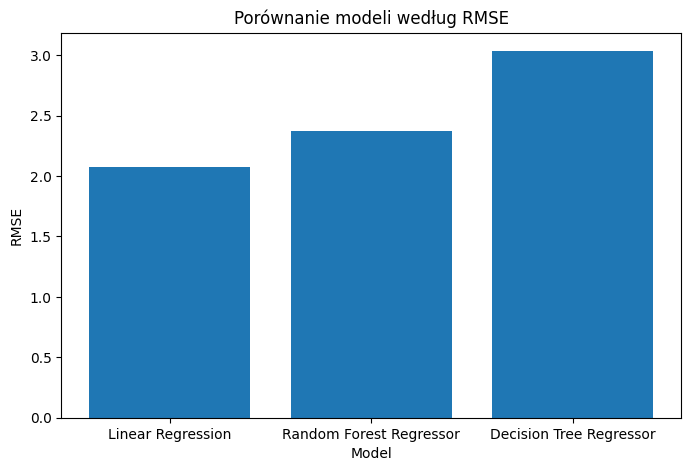

In [75]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Porównanie modeli według RMSE")

plt.show()

### Interpretacja porównania modeli

Porównanie wartości RMSE pokazuje, że najlepszy wynik uzyskała regresja liniowa. Jej RMSE było najniższe, dlatego jej przewidywania były średnio najbliższe rzeczywistym wartościom Performance Index.

Random Forest osiągnął nieco wyższy błąd, natomiast najsłabiej wypadło pojedyncze drzewo decyzyjne. Oznacza to, że w tym zbiorze danych prosta zależność liniowa opisuje wyniki bardzo dobrze.


In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepsze średnie RMSE z walidacji:", -grid_search.best_score_)

Najlepsze parametry: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Najlepsze średnie RMSE z walidacji: 2.2323259962404856


In [77]:
best_forest = grid_search.best_estimator_

best_forest_predictions = best_forest.predict(X_test)

best_forest_mse = mean_squared_error(y_test, best_forest_predictions)
best_forest_rmse = np.sqrt(best_forest_mse)

print(f"Najlepszy Random Forest - Test RMSE: {best_forest_rmse:.2f}")

Najlepszy Random Forest - Test RMSE: 2.27


### Interpretacja tuningu hiperparametrów

Po zastosowaniu GridSearchCV najlepszy model Random Forest uzyskał RMSE na poziomie około 2,27 na zbiorze testowym. Jest to wynik lepszy niż przed tuningiem, gdy RMSE wynosiło około 2,37.

Oznacza to, że automatyczny dobór hiperparametrów poprawił jakość predykcji modelu. Mimo tej poprawy regresja liniowa nadal osiągnęła niższe RMSE, wynoszące około 2,08, dlatego pozostaje najlepszym modelem w tym projekcie.


In [78]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Random Forest po GridSearchCV"
    ],
    "RMSE": [
        rmse_linear,
        tree_rmse,
        forest_rmse,
        best_forest_rmse
    ]
})

final_results = final_results.sort_values(by="RMSE")
final_results

,Model,RMSE
0,Linear Regression,2.075066
3,Random Forest po GridSearchCV,2.267523
2,Random Forest Regressor,2.372552
1,Decision Tree Regressor,3.034488


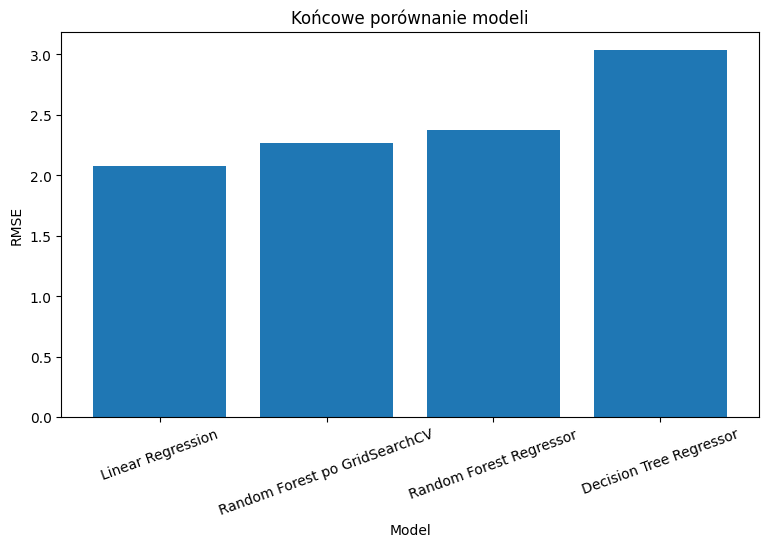

In [79]:
plt.figure(figsize=(9, 5))

plt.bar(final_results["Model"], final_results["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Końcowe porównanie modeli")

plt.xticks(rotation=20)
plt.show()

### Końcowe porównanie modeli

Najniższą wartość RMSE uzyskała regresja liniowa, dlatego była najlepszym modelem w tym projekcie. Random Forest po zastosowaniu GridSearchCV osiągnął lepszy wynik niż jego podstawowa wersja, co pokazuje, że dobór hiperparametrów poprawił jakość predykcji.

Najwyższe RMSE uzyskało pojedyncze drzewo decyzyjne. Ostatecznie wyniki wskazują, że zależności w tym zbiorze danych są w dużej mierze liniowe, dlatego prostszy model regresji liniowej poradził sobie najlepiej.


In [80]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Previous Scores,0.851482
0,Hours Studied,0.142640
3,Sleep Hours,0.002902
4,Sample Question Papers Practiced,0.002440
2,Extracurricular Activities,0.000535


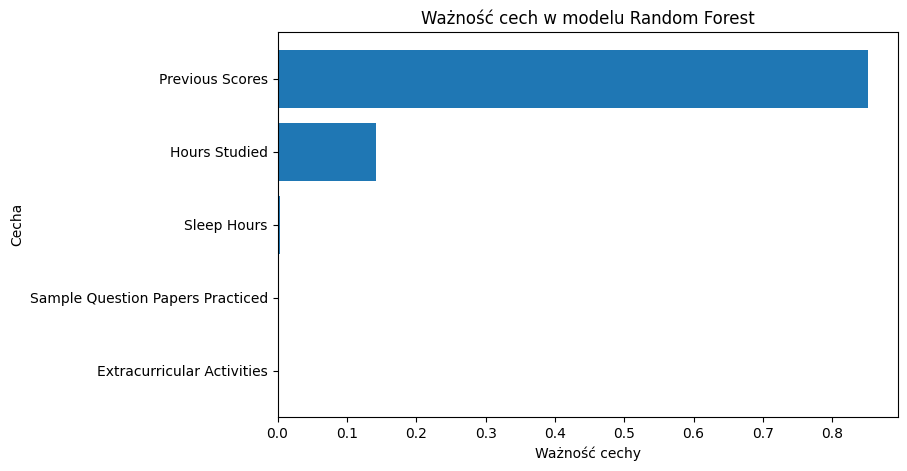

In [81]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Ważność cechy")
plt.ylabel("Cecha")
plt.title("Ważność cech w modelu Random Forest")

plt.gca().invert_yaxis()
plt.show()

Interpretacja ważności cech

Model Random Forest opierał swoje przewidywania głównie na zmiennej Previous Scores, której ważność wyniosła około 0,85. Drugą najważniejszą cechą była liczba godzin nauki, czyli Hours Studied, z ważnością około 0,14.

Pozostałe zmienne miały niewielkie znaczenie dla predykcji modelu. Wynik ten jest zgodny z wcześniejszą analizą korelacji, w której wcześniejsze wyniki również wykazywały najsilniejszy związek z Performance Index.

## Wnioski końcowe

Celem projektu było przewidywanie wartości `Performance Index` na podstawie liczby godzin nauki, wcześniejszych wyników, długości snu, udziału w aktywnościach pozalekcyjnych oraz liczby przećwiczonych arkuszy.

Po wstępnej analizie danych usunięto 127 zduplikowanych obserwacji oraz zakodowano zmienną tekstową `Extracurricular Activities` jako wartości liczbowe. Następnie przeprowadzono analizę korelacji i wizualizację zależności między zmiennymi.

W projekcie porównano trzy modele regresyjne: Linear Regression, Decision Tree Regressor oraz Random Forest Regressor. Najlepszy wynik uzyskała regresja liniowa, dla której RMSE wyniosło około 2,08. Oznacza to, że typowa wielkość błędu predykcji wynosiła około 2 punktów Performance Index.

Model Random Forest przed tuningiem uzyskał RMSE około 2,37. Po zastosowaniu GridSearchCV wynik poprawił się do około 2,27, co pokazuje, że dobór hiperparametrów zwiększył dokładność modelu. Mimo tej poprawy regresja liniowa nadal była najlepszym modelem.

Analiza korelacji oraz ważności cech wskazała, że największe znaczenie dla przewidywania Performance Index miały `Previous Scores` oraz `Hours Studied`. Pozostałe zmienne miały znacznie mniejszy udział w predykcji.

Wyniki sugerują, że zależności w tym zbiorze danych są w dużej mierze liniowe, dlatego prostszy model regresji liniowej poradził sobie lepiej niż bardziej złożone modele drzewiaste. Należy jednak pamiętać, że analiza pokazuje zależności występujące w tym konkretnym zbiorze danych i nie pozwala wnioskować o związkach przyczynowo-skutkowych.
